#Import library

In [2]:
#import Library
!pip install scikit-learn==1.1.3
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")


#Upload data set from Google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/creditcard.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Exploration

In [4]:
print(df.columns)
print(df.describe())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

              

## Mising data

In [5]:
#Missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


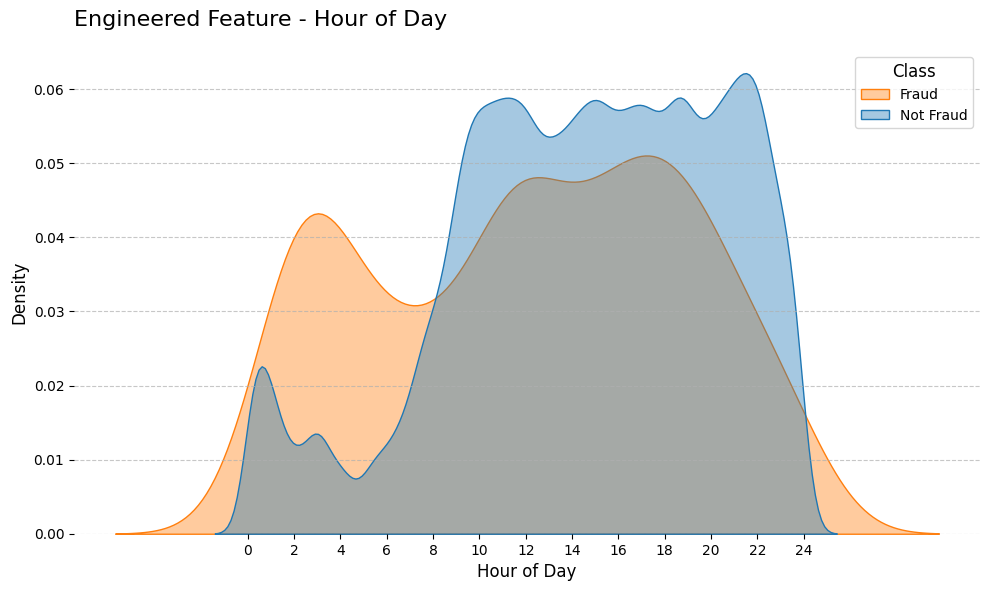

In [6]:
# Convert time to hours and reduce to the 24-hour format
df['hour_of_day'] = (df['Time'] / 3600) % 24

# Create the density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='hour_of_day',
    hue='Class',
    fill=True,
    alpha=0.4,
    common_norm=False
)

# Add labels, title, and customize the x-axis
plt.text(0, 1.05, "Engineered Feature - Hour of Day", fontsize=16, transform=plt.gca().transAxes, ha='left')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(ticks=np.arange(0, 25, 2), labels=np.arange(0, 25, 2))
plt.legend(title='Class', labels=['Fraud', 'Not Fraud'], fontsize=10, title_fontsize=12)

# Remove the frame
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Add grid for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

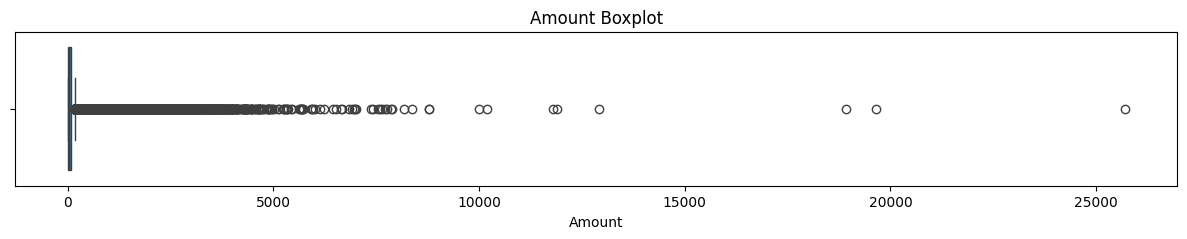

In [7]:
# prompt: create amount boxplot vertical

plt.figure(figsize=(15, 2))
sns.boxplot(x=df['Amount'])
plt.title('Amount Boxplot')
plt.xlabel('Amount')
plt.show()

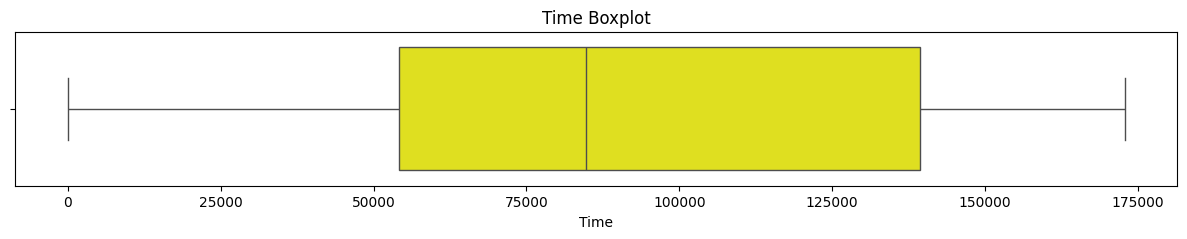

In [8]:

plt.figure(figsize=(15, 2))
sns.boxplot(x=df['Time'], color="yellow")
plt.title('Time Boxplot')
plt.xlabel('Time')
plt.show()

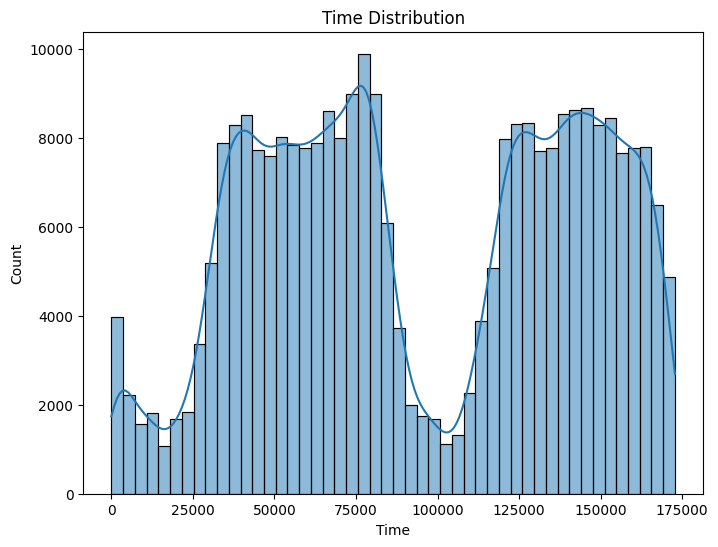

In [9]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Time'], bins=48, kde=True)
plt.title('Time Distribution')
plt.xlabel('Time')
plt.show()


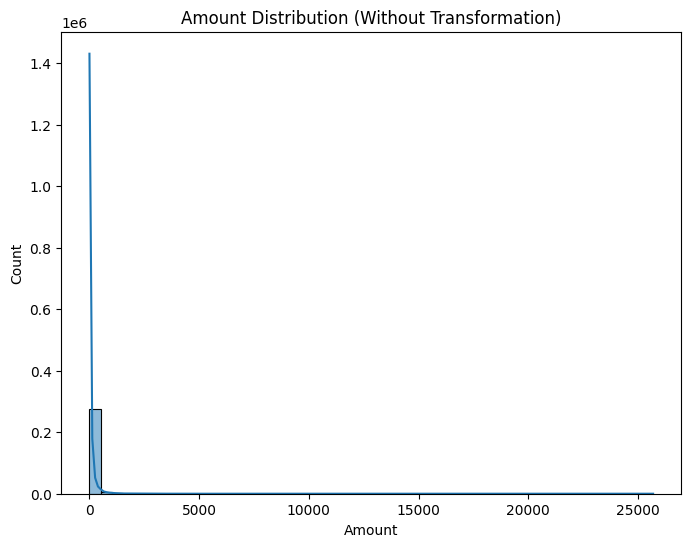

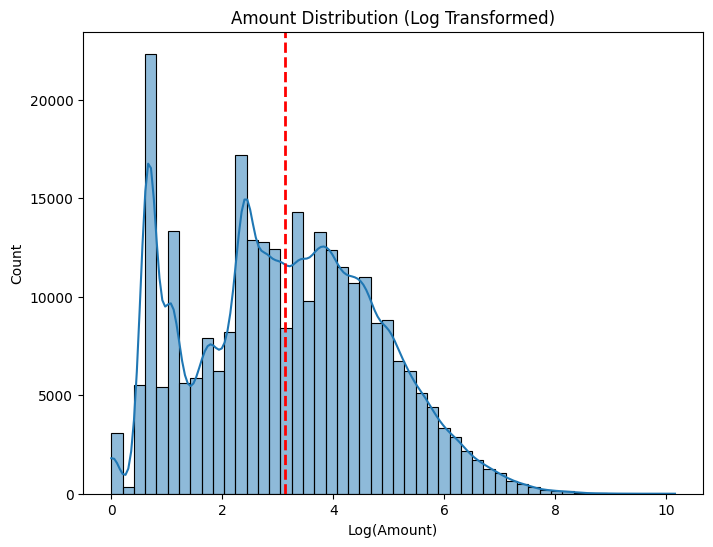

In [10]:
# Without transformation
plt.figure(figsize=(8, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Amount Distribution (Without Transformation)')
plt.xlabel('Amount')
plt.show()


# With log transformation
import numpy as np
plt.figure(figsize=(8, 6))
log_amount = np.log1p(df['Amount'])  # Define log_amount here
sns.histplot(log_amount, bins=50, kde=True)
median_amount = np.median(log_amount)
plt.axvline(median_amount, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_amount:.2f}')
plt.title('Amount Distribution (Log Transformed)')
plt.xlabel('Log(Amount)')
plt.show()


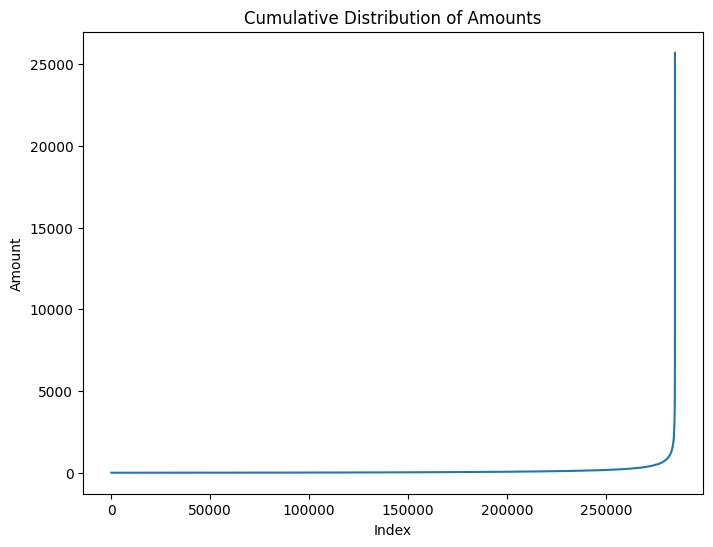

In [11]:
plt.figure(figsize=(8, 6))
df['Amount'].sort_values().reset_index(drop=True).plot(drawstyle='steps')
plt.title('Cumulative Distribution of Amounts')
plt.xlabel('Index')
plt.ylabel('Amount')
plt.show()



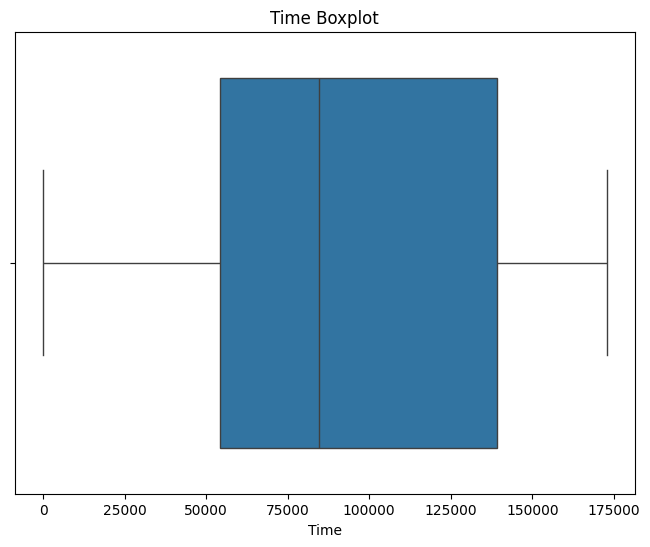

In [12]:
#create time boxplot

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'time' is a column in your DataFrame 'df'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Time'])
plt.title('Time Boxplot')
plt.xlabel('Time')
plt.show()

In [13]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


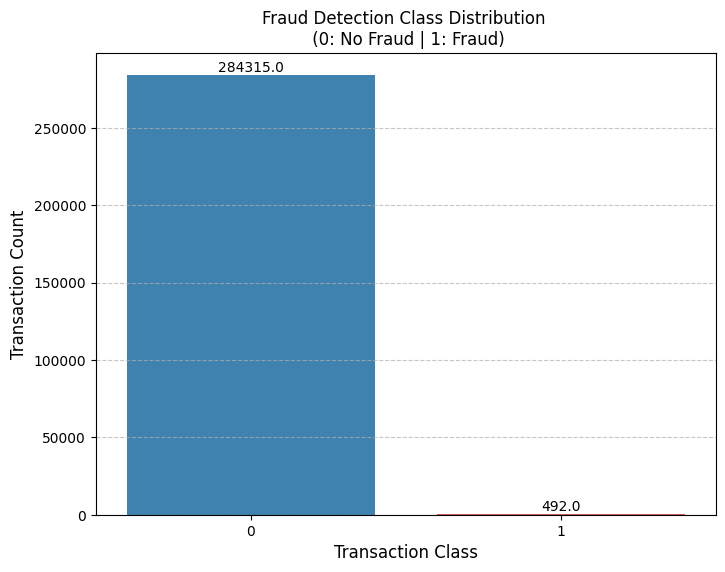

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define improved color palette
colors = ['#2E86C1', '#E74C3C']

#size
plt.figure(figsize=(8, 6))
# Create count plot
sns.countplot(x='Class', data=df, palette=colors)

# Add title and labels
plt.title('Fraud Detection Class Distribution \n (0: No Fraud | 1: Fraud)', fontsize=12)
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)

# Add data labels
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height}',
                       (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom', fontsize=10)

# Add gridlines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

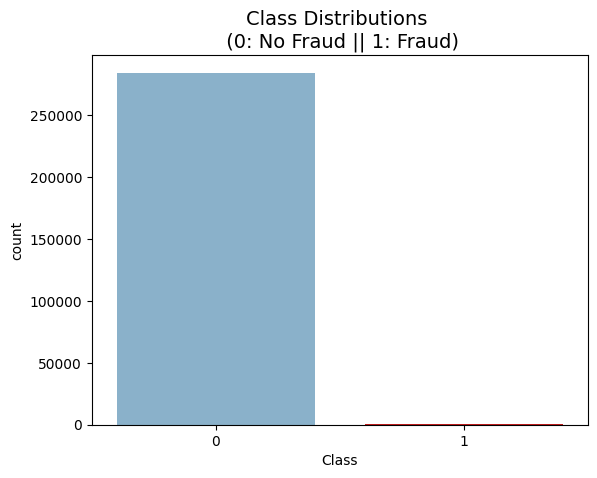

In [15]:
colors = ["#7FB3D5", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

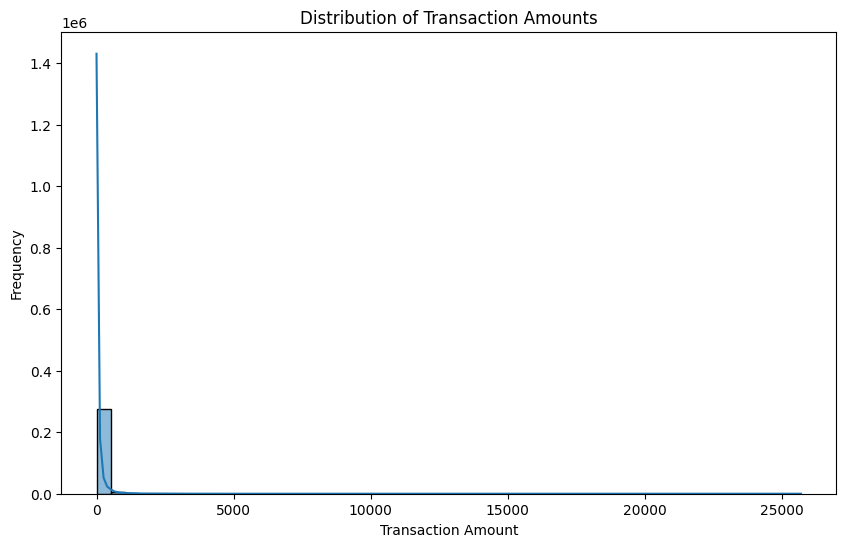

In [16]:
# prompt: plot transaction amount

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and it contains a column named 'Amount'
# If not, replace 'Amount' with the actual column name
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)  # Adjust 'bins' as needed
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

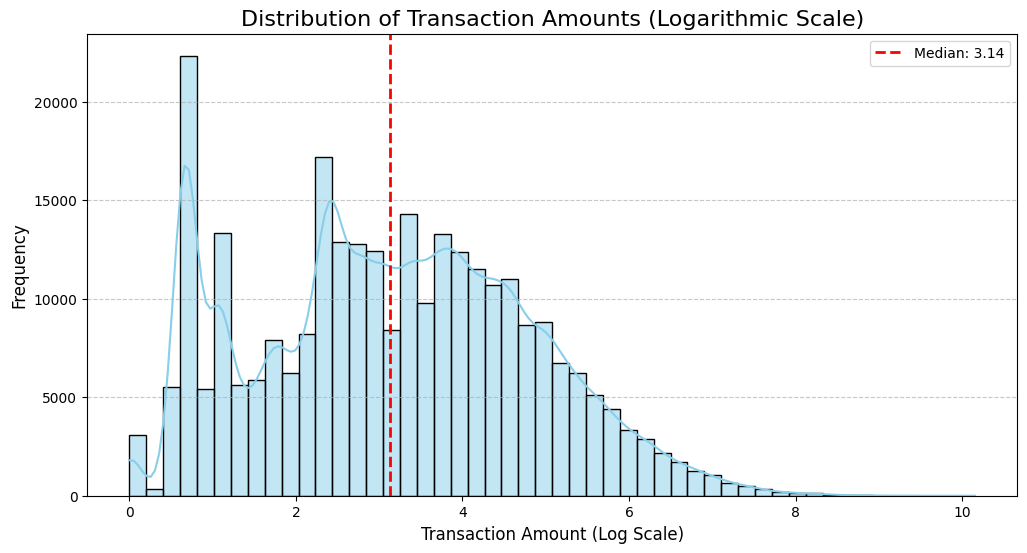

In [17]:
# Improved Transaction Amount Plot
plt.figure(figsize=(12, 6))

# Logarithmic transformation to handle skewed data
log_amount = np.log1p(df['Amount'])

sns.histplot(log_amount, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts (Logarithmic Scale)', fontsize=16)
plt.xlabel('Transaction Amount (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a vertical line at the median
median_amount = np.median(log_amount)
plt.axvline(median_amount, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_amount:.2f}')


plt.legend()  # Show the legend for the median line

plt.grid(axis='y', linestyle='--', alpha=0.7) # add a grid

plt.show()

In [18]:
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour_of_day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.000278
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.000278
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.000556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.996111
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.996389
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.996667
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.996667


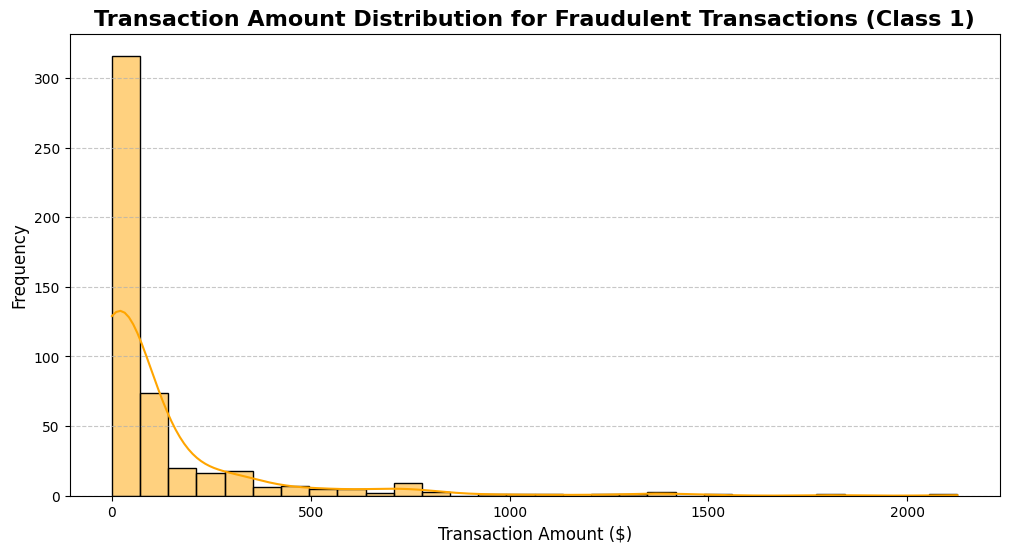

In [19]:


# Filter for Class 1 Transactions
class_1_transactions = df[df['Class'] == 1]

# Create a More Beautiful Plot
plt.figure(figsize=(12, 6))
sns.histplot(
    class_1_transactions['Amount'],
    bins=30,
    color='orange',
    kde=True,  # Add density curve
    edgecolor='black'
)

# Add Titles and Labels
plt.title('Transaction Amount Distribution for Fraudulent Transactions (Class 1)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [20]:
df.drop('Time', axis=1, inplace=True)

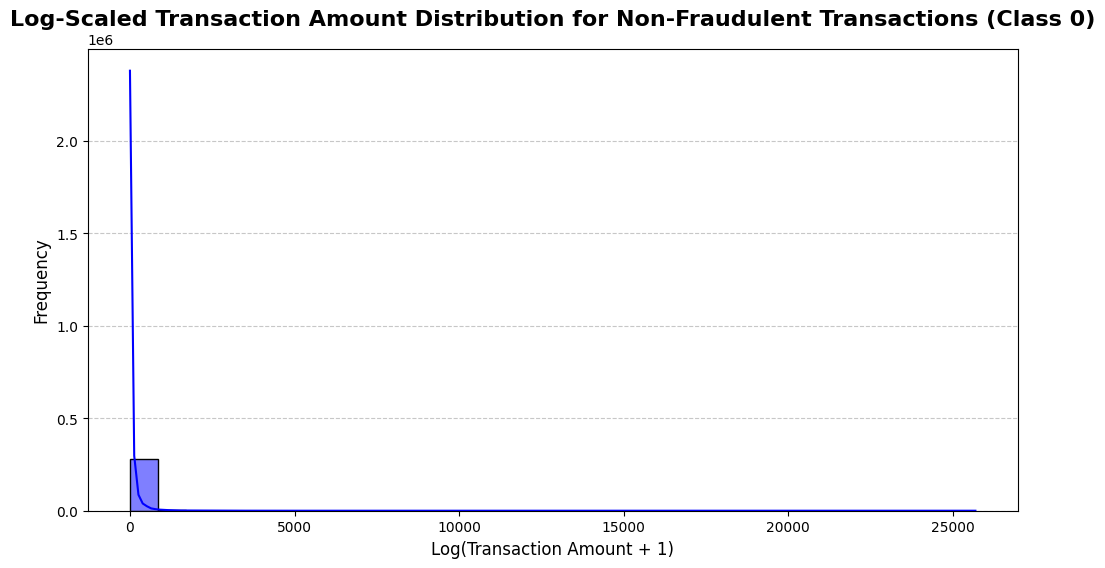

In [21]:
# Filter for Class 1 Transactions
class_0_transactions = df[df['Class'] == 0]

# Create a More Beautiful Plot with Log Scaling
plt.figure(figsize=(12, 6))
sns.histplot(
    class_0_transactions['Amount'],  # Log-scaling
    bins=30,
    color='blue',
    kde=True,      # Add density curve
    edgecolor='black'
)

# Add Titles and Labels
plt.title('Log-Scaled Transaction Amount Distribution for Non-Fraudulent Transactions (Class 0)',
          fontsize=16, fontweight='bold')
plt.xlabel('Log(Transaction Amount + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

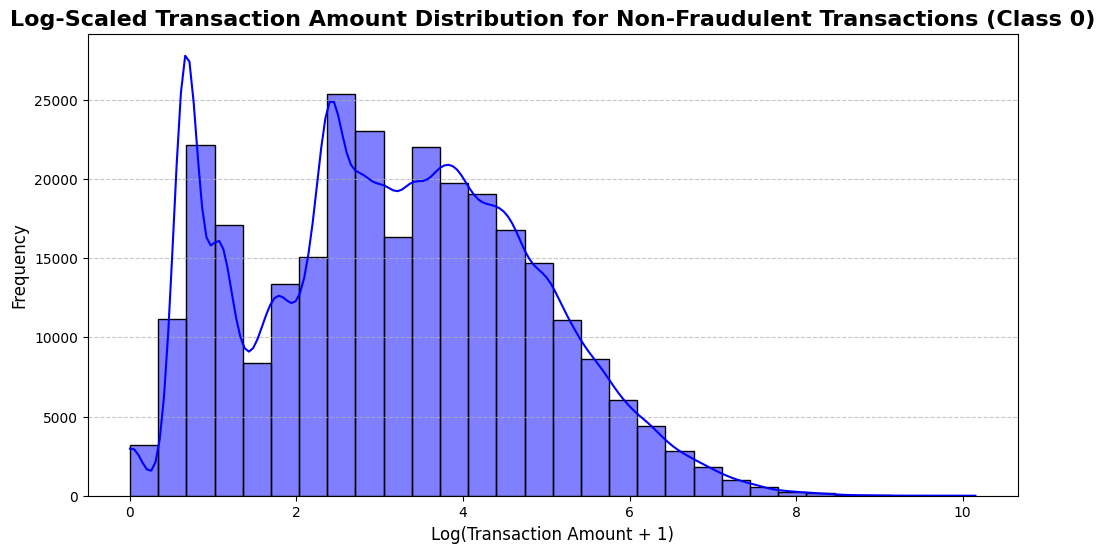

In [22]:
# Filter for Class 1 Transactions
class_0_transactions = df[df['Class'] == 0]

# Create a More Beautiful Plot with Log Scaling
plt.figure(figsize=(12, 6))
sns.histplot(
    np.log1p(class_0_transactions['Amount']),  # Log-scaling
    bins=30,
    color='blue',
    kde=True,      # Add density curve
    edgecolor='black'
)

# Add Titles and Labels
plt.title('Log-Scaled Transaction Amount Distribution for Non-Fraudulent Transactions (Class 0)',
          fontsize=16, fontweight='bold')
plt.xlabel('Log(Transaction Amount + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Correlation

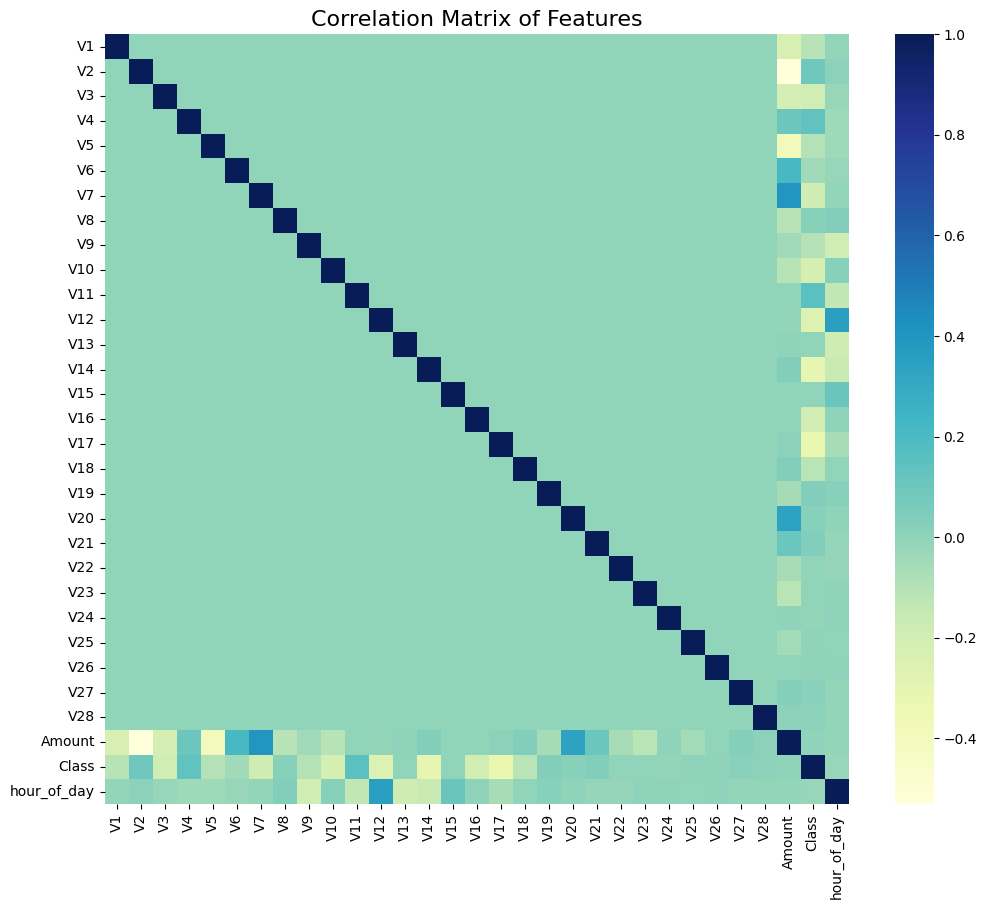

In [23]:
# prompt: create a correlation heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

Based on the correlation matirx, there is a small correlation between the features apart from Amont, class(target) and time. This also means that the features are mostly independence from each other.


In [24]:
# Calculate the correlation between Taget and features.
x = df.corr()['Class'][:31]
print(x)

V1            -0.101347
V2             0.091289
V3            -0.192961
V4             0.133447
V5            -0.094974
V6            -0.043643
V7            -0.187257
V8             0.019875
V9            -0.097733
V10           -0.216883
V11            0.154876
V12           -0.260593
V13           -0.004570
V14           -0.302544
V15           -0.004223
V16           -0.196539
V17           -0.326481
V18           -0.111485
V19            0.034783
V20            0.020090
V21            0.040413
V22            0.000805
V23           -0.002685
V24           -0.007221
V25            0.003308
V26            0.004455
V27            0.017580
V28            0.009536
Amount         0.005632
Class          1.000000
hour_of_day   -0.017082
Name: Class, dtype: float64


<Axes: title={'center': 'Correlation Of Features With Target Variable'}>

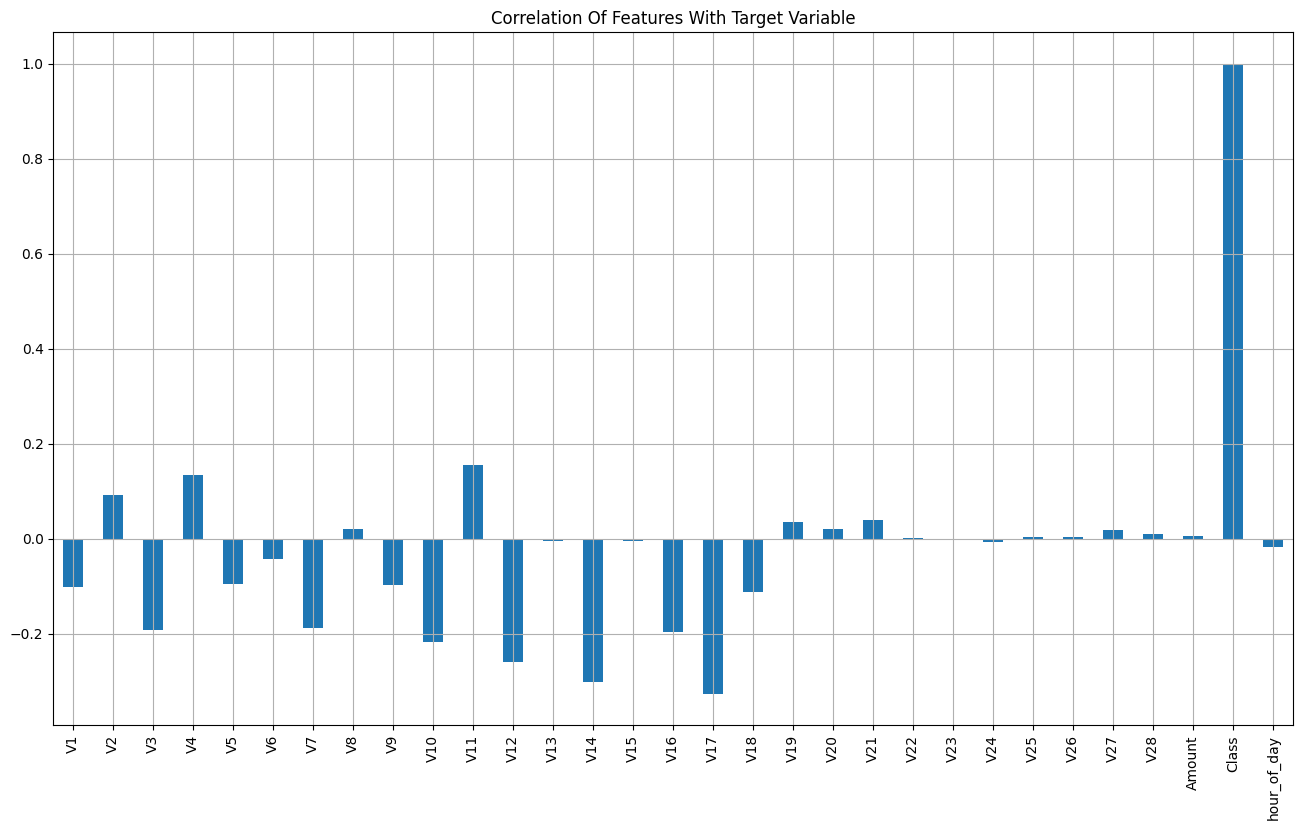

In [25]:
# Create a bar plot to visualize the correlation of features with the target variable 'Class'
x.plot.bar(figsize=(16, 9), title="Correlation Of Features With Target Variable", grid=True)

In [26]:
# Calculate the correlation coefficients between 'Class' and all columns
y = df.corr()['Class']

# Create a copy of the DataFrame df
df2 = df.copy()

# Iterate through columns and drop those with absolute correlation less than 0.13
for i in df.columns:
    if abs(y[i]) < 0.13:
        df2.drop(columns=[i], inplace=True)

In [27]:
df2.head()

,V3,V4,V7,V10,V11,V12,V14,V16,V17,Class
0,2.536347,1.378155,0.239599,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0
1,0.166480,0.448154,-0.078803,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,0
2,1.773209,0.379780,0.791461,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,0
3,1.792993,-0.863291,0.237609,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,0
4,1.548718,0.403034,0.592941,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,0


<Axes: >

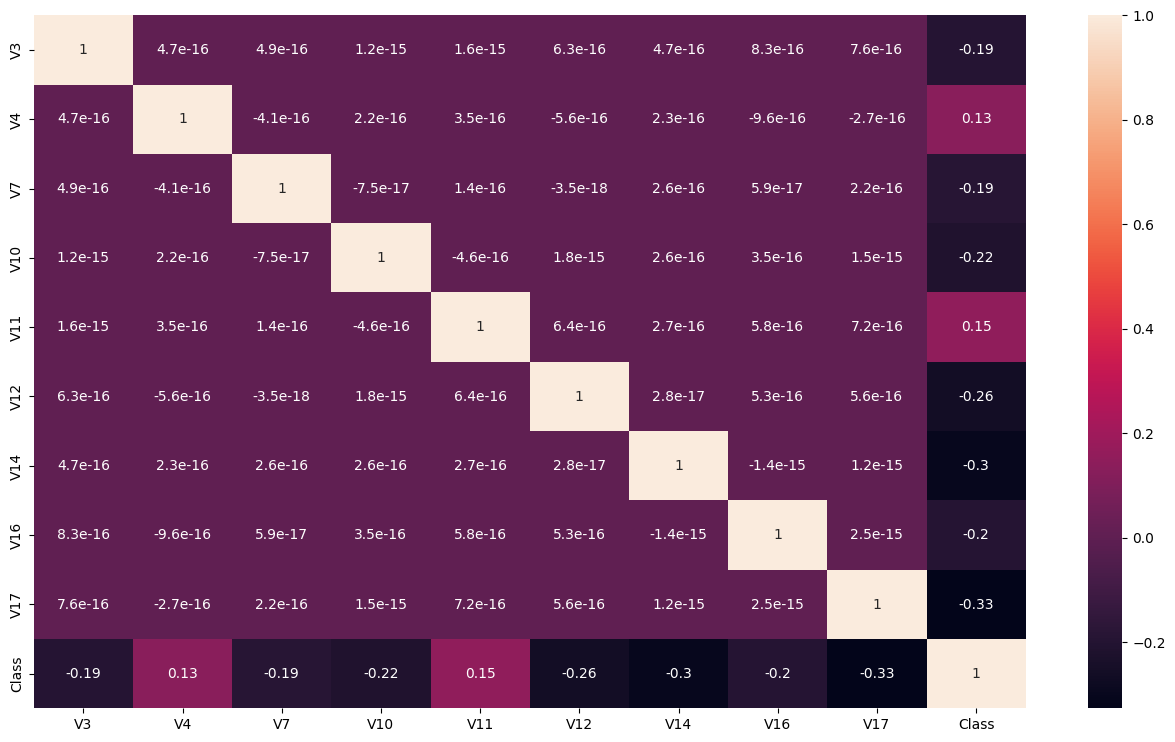

In [28]:
# Create a figure with a specific size for the heatmap
plt.figure(figsize=(16, 9))

# Create a heatmap to visualize the correlation matrix of the DataFrame df2
sns.heatmap(df2.corr(), annot=True)

<Axes: title={'center': 'Top Correlated Features With The Target Variable'}>

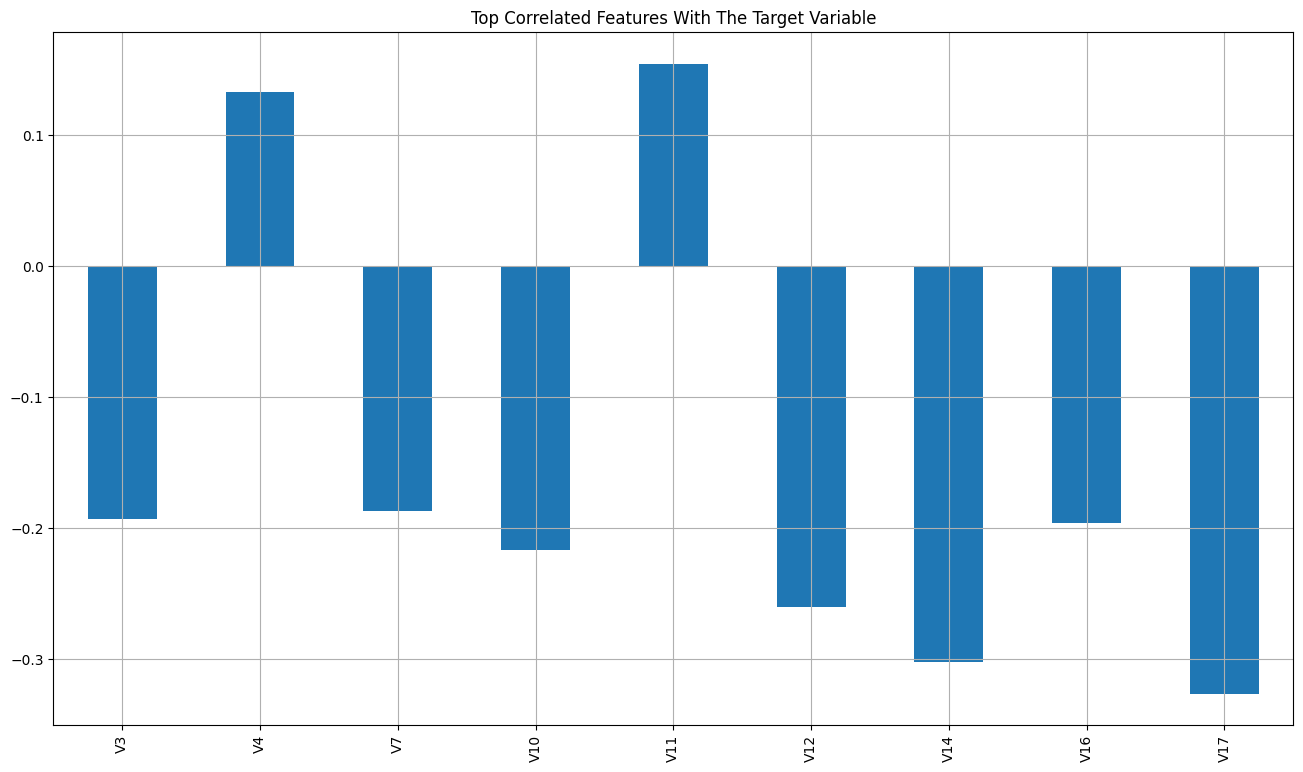

In [29]:
# Calculate the correlation coefficients between the 'Class' column
x = df2.corr()['Class'][:9]

# Create a bar plot to visualize the top correlated features with the target variable 'Class'
x.plot.bar(figsize=(16, 9), title="Top Correlated Features With The Target Variable", grid=True)

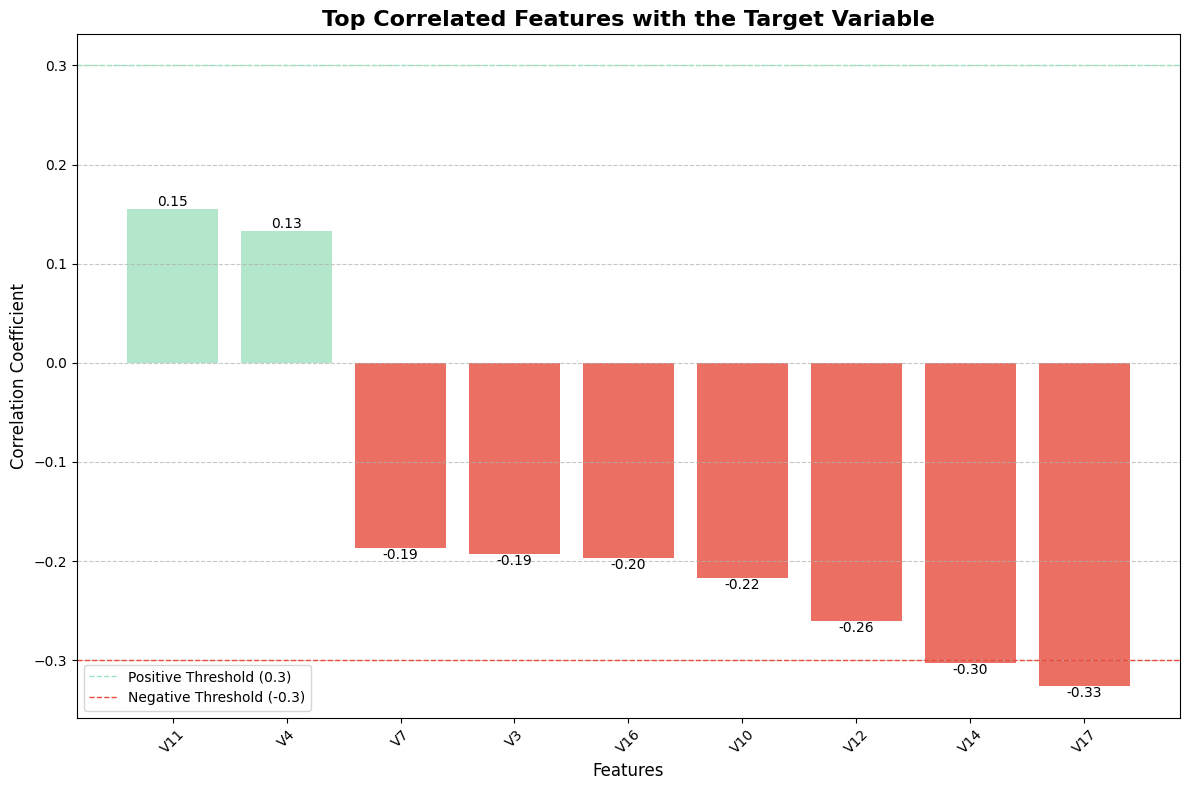

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort correlations for better visual clarity
x = df2.corr()['Class'][:9].sort_values(ascending=False)

# Set up the figure
plt.figure(figsize=(12, 8))

# Create a bar plot with custom color palette
colors = ['#9FE2BF' if value > 0 else '#E74C3C' for value in x]  # Positive correlations in green, negative in red
bars = plt.bar(x.index, x.values, color=colors, alpha=0.8)

# Add annotations (correlation values above bars)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center', va='bottom' if bar.get_height() > 0 else 'top', fontsize=10)

# Customize title and labels
plt.title("Top Correlated Features with the Target Variable", fontsize=16, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Correlation Coefficient", fontsize=12)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight important features (optional)
plt.axhline(y=0.3, color='#9FE2BF', linestyle='--', linewidth=1, label='Positive Threshold (0.3)')
plt.axhline(y=-0.3, color='#E74C3C', linestyle='--', linewidth=1, label='Negative Threshold (-0.3)')
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


## Feature scaling

In [31]:
X = df.drop(['Class','V1','V2','V5','V6','V8','V9','V13','V15','V18','V19','V20', 'V21','V22','V23','V24','V25','V26','V27','V28'], axis=1)
y = df['Class']

#Oversampling using SMOTE

In [32]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

rs = RobustScaler()
sd = StandardScaler()
# Scale 'Amount' and 'hour_of_day' in x_train
x_train['scaled_amount'] = rs.fit_transform(x_train['Amount'].values.reshape(-1,1))
x_train['scaled_hour_of_day'] = sd.fit_transform(x_train['hour_of_day'].values.reshape(-1,1))

x_train.drop(['hour_of_day', 'Amount'], axis=1, inplace=True)


# Scale 'Amount' and 'hour_of_day' in x_test
x_test['scaled_amount'] = rs.transform(x_test[['Amount']])
x_test['scaled_hour_of_day'] = sd.transform(x_test[['hour_of_day']])

# Drop original columns from test set
x_test.drop(['hour_of_day', 'Amount'], axis=1, inplace=True)


print("Transaction Number x_train dataset: ", x_train.shape)
print("Transaction Number y_train dataset: ", y_train.shape)
print("Transaction Number x_test dataset: ", x_test.shape)
print("Transaction Number y_test dataset: ", y_test.shape)

print("Before OverSampling, counts of label '1': {}".format(sum(y_train==1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train==0)))



Transaction Number x_train dataset:  (227845, 11)
Transaction Number y_train dataset:  (227845,)
Transaction Number x_test dataset:  (56962, 11)
Transaction Number y_test dataset:  (56962,)
Before OverSampling, counts of label '1': 394
Before OverSampling, counts of label '0': 227451 



In [33]:
x_train.head()

,V3,V4,V7,V10,V11,V12,V14,V16,V17,scaled_amount,scaled_hour_of_day
36001,1.045810,2.805989,0.032736,0.499167,-0.572665,0.346009,-0.098964,0.181411,-0.124345,0.387101,-0.663374
12844,1.805627,1.903416,-0.824802,-0.658751,1.281502,-1.430087,1.403024,-1.331766,1.964590,-0.070789,-1.412827
2873,0.865329,-2.138000,1.072114,-1.109522,-1.016020,-0.654945,0.317345,-0.372642,-0.674725,-0.293788,-2.367383
145263,-0.585348,-0.875347,1.073860,0.154307,0.882673,0.547890,-1.253302,0.495221,-0.153212,-0.156967,-2.465002
186658,-1.936511,-0.818288,-0.151627,0.428729,1.136666,0.273476,-1.222134,1.298149,0.912921,0.251259,-0.547303


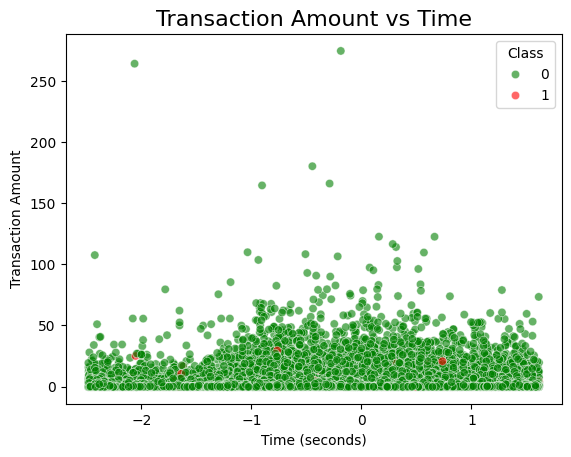

In [34]:
# Add fraud labels for comparison
train_data = x_train.copy()
train_data['Class'] = y_train

# Scatter plot
sns.scatterplot(data=train_data, x='scaled_hour_of_day', y='scaled_amount', hue='Class',
                palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title('Transaction Amount vs Time', fontsize=16)
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.show()


In [35]:
sm = SMOTE(random_state=2)
# Use fit_resample instead of fit_sample
x_train_s, y_train_s = sm.fit_resample(x_train, y_train.ravel())

print('After OverSampling, the shape of train_x: {}'.format(x_train_s.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_s.shape))

print("After OverSampling, counts of label '1', %: {}".format(sum(y_train_s==1)/len(y_train_s)*100.0,2))
print("After OverSampling, counts of label '0', %: {}".format(sum(y_train_s==0)/len(y_train_s)*100.0,2))


After OverSampling, the shape of train_x: (454902, 11)
After OverSampling, the shape of train_y: (454902,) 

After OverSampling, counts of label '1', %: 50.0
After OverSampling, counts of label '0', %: 50.0


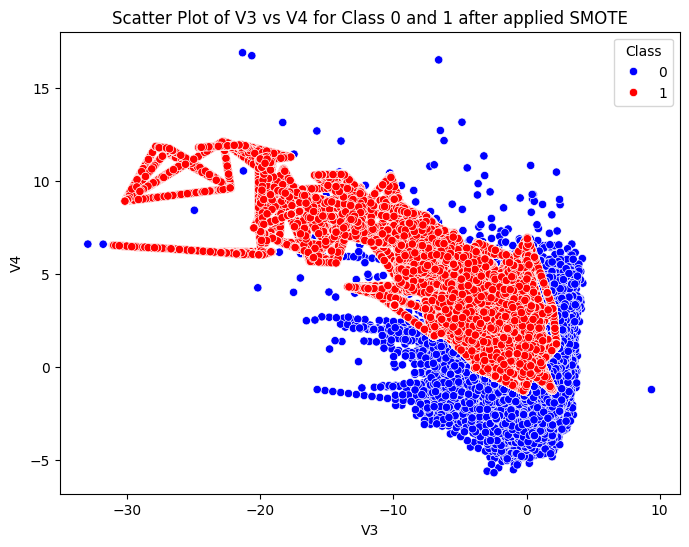

In [36]:
# prompt: scattering plot plot for class 1 and 0 on x_train_s between v3 and v4

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming x_train_s and y_train_s are already defined from the previous code
# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({'v3': x_train_s['V3'], 'v4': x_train_s['V4'], 'Class': y_train_s})

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='v3', y='v4', hue='Class', data=plot_data, palette={0: 'blue', 1: 'red'})
plt.title('Scatter Plot of V3 vs V4 for Class 0 and 1 after applied SMOTE')
plt.xlabel('V3')
plt.ylabel('V4')
plt.show()

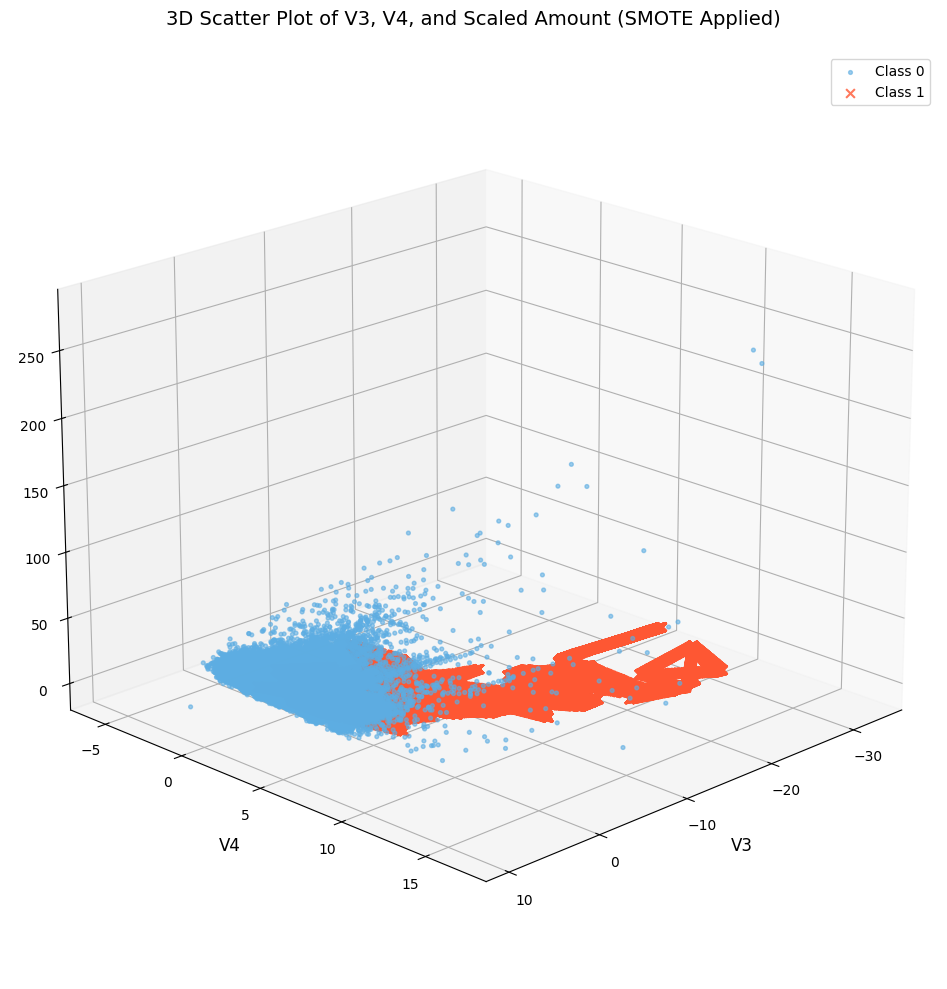

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({
    'v3': x_train_s['V3'],
    'v4': x_train_s['V4'],
    'Class': y_train_s,
    'scaled_amount': x_train_s['scaled_amount']
})

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for Class 0
ax.scatter(plot_data[plot_data['Class'] == 0]['v3'],
           plot_data[plot_data['Class'] == 0]['v4'],
           plot_data[plot_data['Class'] == 0]['scaled_amount'],
           c='#5DADE2', marker='.', alpha=0.6, s=30, label='Class 0')

# Scatter plot for Class 1
ax.scatter(plot_data[plot_data['Class'] == 1]['v3'],
           plot_data[plot_data['Class'] == 1]['v4'],
           plot_data[plot_data['Class'] == 1]['scaled_amount'],
           c='#FF5733', marker='x', alpha=0.8, s=40, label='Class 1')

# Customize the plot
ax.set_xlabel('V3', fontsize=12, labelpad=10)
ax.set_ylabel('V4', fontsize=12, labelpad=10)
ax.set_zlabel('Scaled Amount', fontsize=12, labelpad=10)
ax.set_title('3D Scatter Plot of V3, V4, and Scaled Amount (SMOTE Applied)', fontsize=14, pad=20)

# Adjust grid and view
ax.grid(True)
ax.view_init(elev=20, azim=45)  # Rotate view for better perspective

# Add legend
ax.legend(fontsize=10, loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()


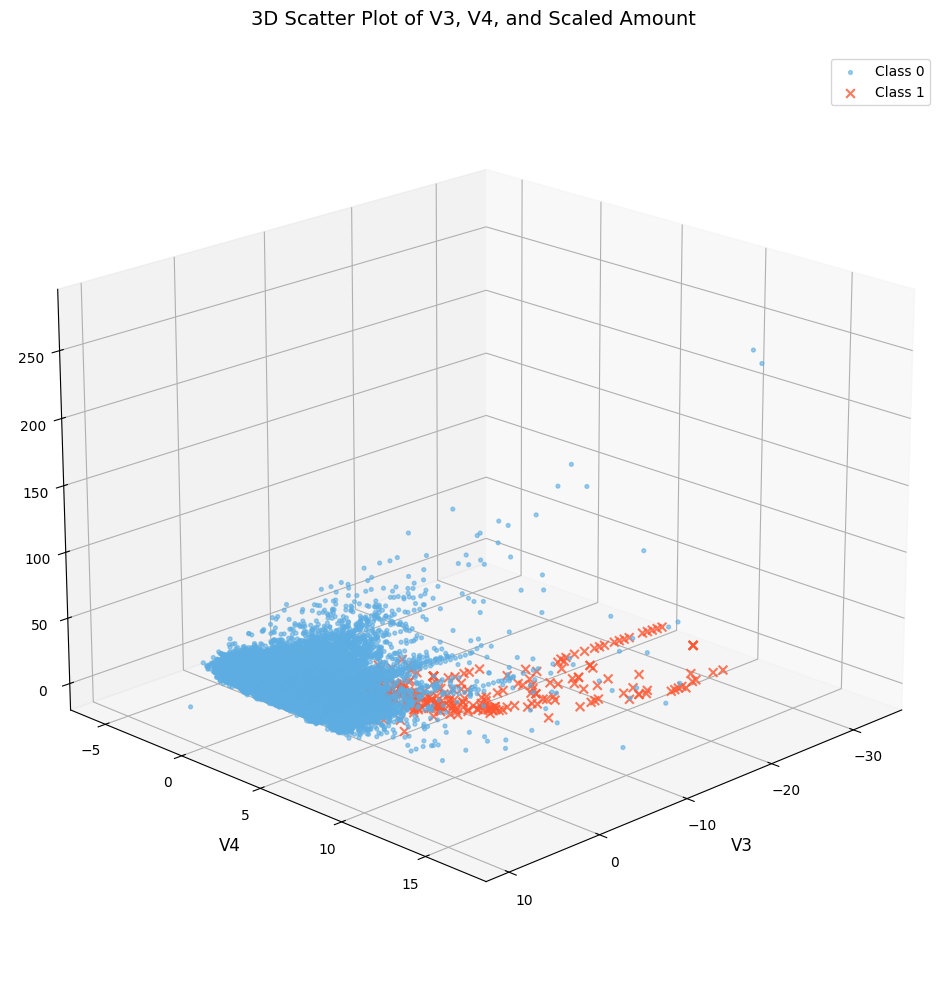

In [38]:
# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({
    'v3': x_train['V3'],
    'v4': x_train['V4'],
    'Class': y_train,
    'scaled_amount': x_train['scaled_amount']
})

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for Class 0
ax.scatter(plot_data[plot_data['Class'] == 0]['v3'],
           plot_data[plot_data['Class'] == 0]['v4'],
           plot_data[plot_data['Class'] == 0]['scaled_amount'],
           c='#5DADE2', marker='.', alpha=0.6, s=30, label='Class 0')

# Scatter plot for Class 1
ax.scatter(plot_data[plot_data['Class'] == 1]['v3'],
           plot_data[plot_data['Class'] == 1]['v4'],
           plot_data[plot_data['Class'] == 1]['scaled_amount'],
           c='#FF5733', marker='x', alpha=0.8, s=40, label='Class 1')

# Customize the plot
ax.set_xlabel('V3', fontsize=12, labelpad=10)
ax.set_ylabel('V4', fontsize=12, labelpad=10)
ax.set_zlabel('Scaled Amount', fontsize=12, labelpad=10)
ax.set_title('3D Scatter Plot of V3, V4, and Scaled Amount', fontsize=14, pad=20)

# Adjust grid and view
ax.grid(True)
ax.view_init(elev=20, azim=45)  # Rotate view for better perspective

# Add legend
ax.legend(fontsize=10, loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()

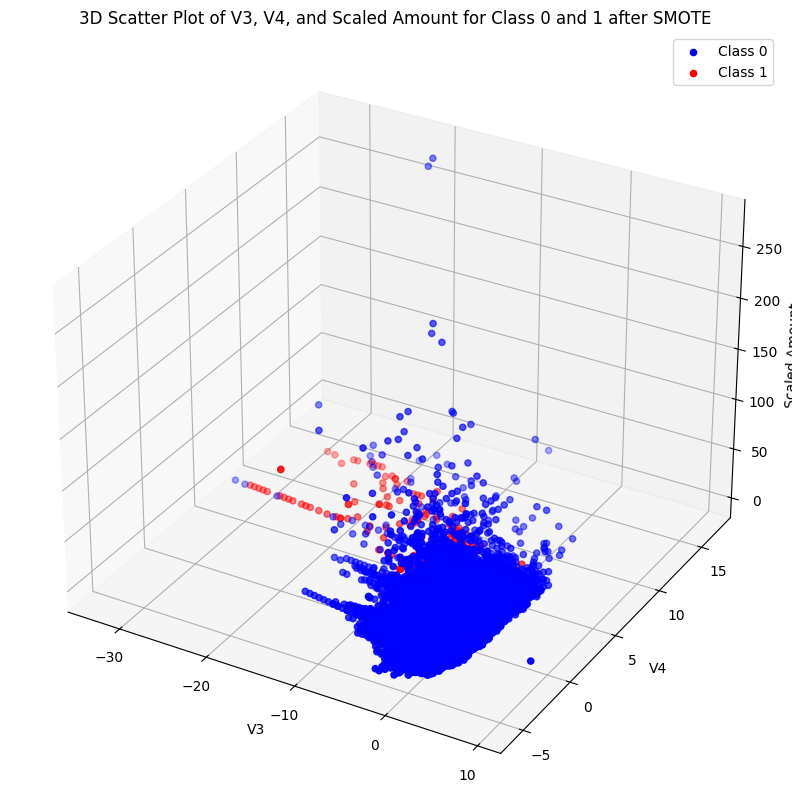

In [39]:
plot_data = pd.DataFrame({'v3': x_train['V3'], 'v4': x_train['V4'], 'Class': y_train, 'scaled_amount': x_train['scaled_amount']})

# Create the 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for class 0
ax.scatter(plot_data[plot_data['Class'] == 0]['v3'],
           plot_data[plot_data['Class'] == 0]['v4'],
           plot_data[plot_data['Class'] == 0]['scaled_amount'],
           c='blue', label='Class 0')

# Scatter plot for class 1
ax.scatter(plot_data[plot_data['Class'] == 1]['v3'],
           plot_data[plot_data['Class'] == 1]['v4'],
           plot_data[plot_data['Class'] == 1]['scaled_amount'],
           c='red', label='Class 1')

# Customize the plot
ax.set_xlabel('V3')
ax.set_ylabel('V4')
ax.set_zlabel('Scaled Amount')
ax.set_title('3D Scatter Plot of V3, V4, and Scaled Amount for Class 0 and 1 after SMOTE')
ax.legend()

plt.show()

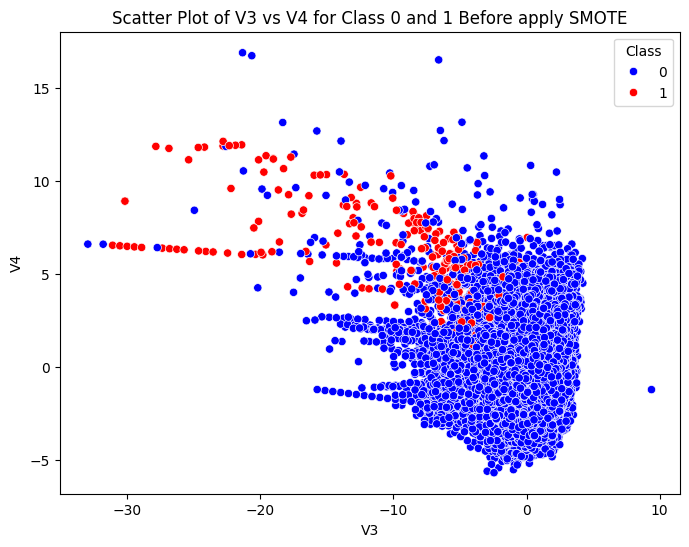

In [40]:
# Assuming x_train_s and y_train_s are already defined from the previous code
# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({'v3': x_train['V3'], 'v4': x_train['V4'], 'Class': y_train})

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='v3', y='v4', hue='Class', data=plot_data, palette={0: 'blue', 1: 'red'})
plt.title('Scatter Plot of V3 vs V4 for Class 0 and 1 Before apply SMOTE')
plt.xlabel('V3')
plt.ylabel('V4')
plt.show()

In [41]:
x_train_s

,V3,V4,V7,V10,V11,V12,V14,V16,V17,scaled_amount,scaled_hour_of_day
0,1.045810,2.805989,0.032736,0.499167,-0.572665,0.346009,-0.098964,0.181411,-0.124345,0.387101,-0.663374
1,1.805627,1.903416,-0.824802,-0.658751,1.281502,-1.430087,1.403024,-1.331766,1.964590,-0.070789,-1.412827
2,0.865329,-2.138000,1.072114,-1.109522,-1.016020,-0.654945,0.317345,-0.372642,-0.674725,-0.293788,-2.367383
3,-0.585348,-0.875347,1.073860,0.154307,0.882673,0.547890,-1.253302,0.495221,-0.153212,-0.156967,-2.465002
4,-1.936511,-0.818288,-0.151627,0.428729,1.136666,0.273476,-1.222134,1.298149,0.912921,0.251259,-0.547303
...,...,...,...,...,...,...,...,...,...,...,...
454897,-3.460467,2.334777,-2.453609,-4.760857,4.443886,-4.922841,-7.129546,-3.664805,-7.175466,2.351272,0.088473
454898,-5.510033,6.972922,-3.083847,-4.438257,4.529286,-7.715592,-7.864747,-3.340209,-4.291931,1.399944,-0.835892
454899,-4.383936,5.557713,-6.665909,-6.528234,3.431839,-7.941706,-7.735505,-7.578050,-14.133264,-0.238199,-0.778976
454900,-26.826799,11.719032,-41.373082,-24.367853,3.420649,-9.635760,0.118785,-6.593648,-12.954816,-0.306819,-1.738463


## RandomeForest using SMOTE

In [42]:

rf = RandomForestClassifier(n_estimators=100, min_samples_split=10, min_samples_leaf=1, max_leaf_nodes=None,
           oob_score=True, n_jobs=-1, random_state=1)

rf.fit(x_train_s, y_train_s)
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.79      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962



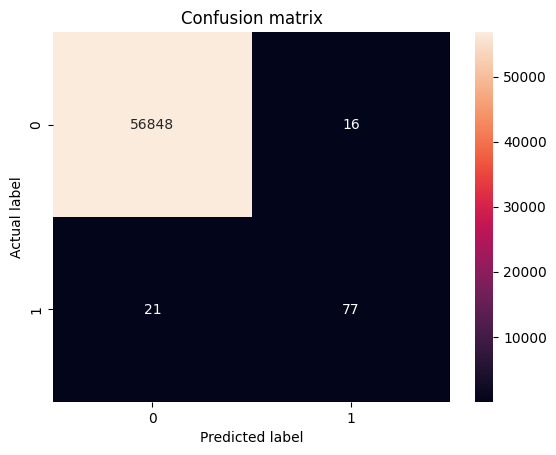

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

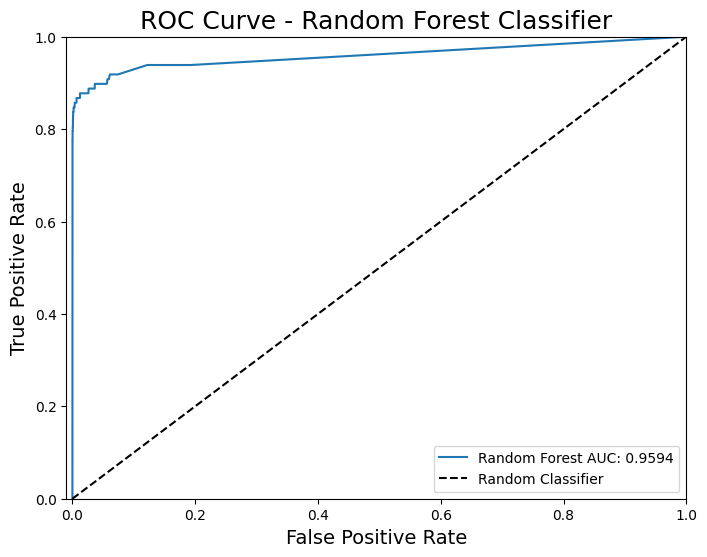

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Generate predicted probabilities for ROC curve
rf_probs = rf.predict_proba(x_test)[:, 1]

# Calculate ROC metrics
rf_fpr, rf_tpr, rf_threshold = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - Random Forest Classifier', fontsize=18)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC: {rf_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.axis([-0.01, 1, 0, 1])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()

In [45]:
print(f"ROC AUC Score: {rf_auc}")

ROC AUC Score: 0.9593621336407383


## XGBoost Using SMOTE

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.81      0.75        98

    accuracy                           1.00     56962
   macro avg       0.85      0.90      0.87     56962
weighted avg       1.00      1.00      1.00     56962



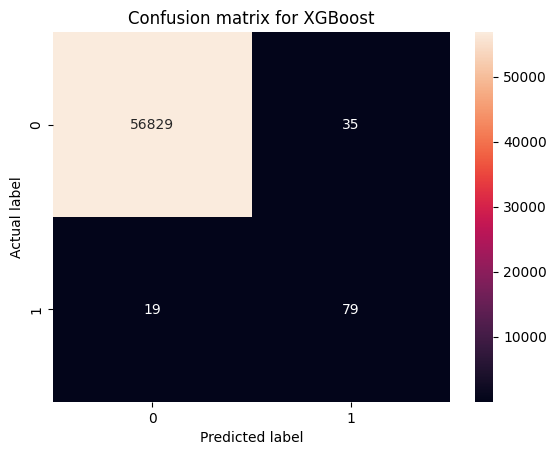

In [46]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(n_estimators = 5000, max_depth = 30, learning_rate = 0.01)

# Train the model
xgb_model.fit(x_train_s, y_train_s)

# Make predictions
y_pred_xgb = xgb_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred_xgb))

# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d")
plt.title('Confusion matrix for XGBoost')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

ROC AUC Score: 0.9767605199085824


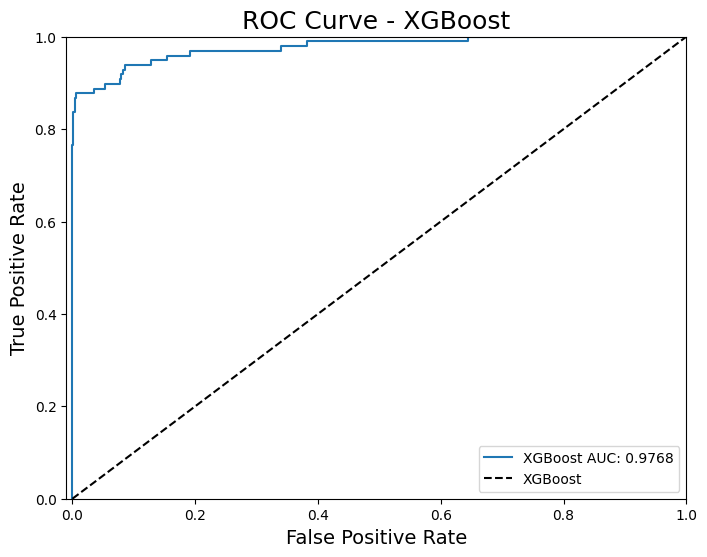

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming 'xgb_model' is your trained XGBoost classifier object
xgb_probs = xgb_model.predict_proba(x_test)[:, 1]

# Calculate ROC metrics
xgb_fpr, xgb_tpr, xgb_threshold = roc_curve(y_test, xgb_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"ROC AUC Score: {xgb_auc}")
# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - XGBoost', fontsize=18)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost AUC: {xgb_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='XGBoost')
plt.axis([-0.01, 1, 0, 1])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()

## Logistic Regression Using SMOTE

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.88      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.98      0.99     56962



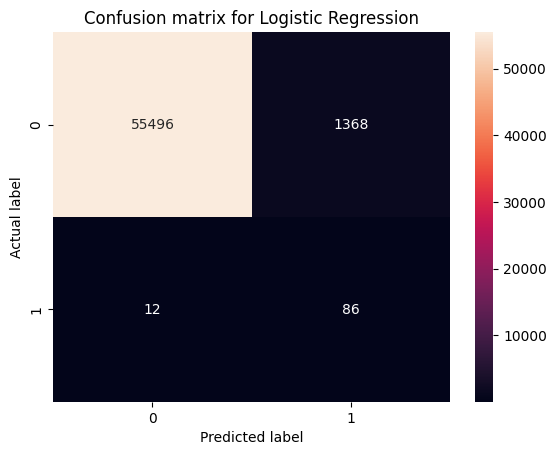

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Initialize Logistic Regression model
logreg_model = LogisticRegression()

# Train the model
logreg_model.fit(x_train_s, y_train_s)

# Make predictions
y_pred_logreg = logreg_model.predict(x_test)

# Evaluate the model
print(classification_report(y_test, y_pred_logreg))

# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot=True, fmt="d")
plt.title('Confusion matrix for Logistic Regression')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

ROC AUC Score: 0.9809421763922226


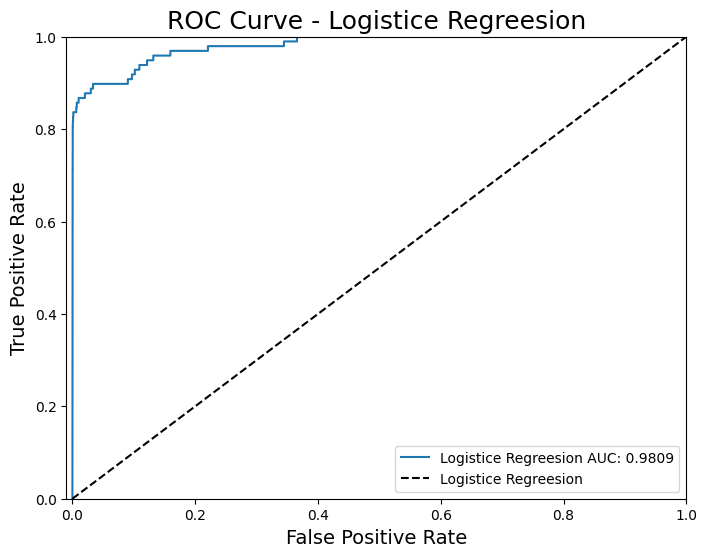

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use the correct variable name 'logreg_model'
lg_probs = logreg_model.predict_proba(x_test)[:, 1]

# Calculate ROC metrics
lg_fpr, lg_tpr, lg_threshold = roc_curve(y_test, lg_probs)
lg_auc = roc_auc_score(y_test, lg_probs)

print(f"ROC AUC Score: {lg_auc}")
# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - Logistice Regreesion', fontsize=18)
plt.plot(lg_fpr, lg_tpr, label=f'Logistice Regreesion AUC: {lg_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Logistice Regreesion')
plt.axis([-0.01, 1, 0, 1])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()

#Undersampling using Tomek

## RandomForest using Tomek

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             accuracy_score)
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import TomekLinks

# Apply Tomek Links resampling
tl = TomekLinks(sampling_strategy='majority')
x_train_tl, y_train_tl = tl.fit_resample(x_train, y_train)

In [51]:
x_train_tl

,V3,V4,V7,V10,V11,V12,V14,V16,V17,scaled_amount,scaled_hour_of_day
0,1.045810,2.805989,0.032736,0.499167,-0.572665,0.346009,-0.098964,0.181411,-0.124345,0.387101,-0.663374
1,1.805627,1.903416,-0.824802,-0.658751,1.281502,-1.430087,1.403024,-1.331766,1.964590,-0.070789,-1.412827
2,0.865329,-2.138000,1.072114,-1.109522,-1.016020,-0.654945,0.317345,-0.372642,-0.674725,-0.293788,-2.367383
3,-0.585348,-0.875347,1.073860,0.154307,0.882673,0.547890,-1.253302,0.495221,-0.153212,-0.156967,-2.465002
4,-1.936511,-0.818288,-0.151627,0.428729,1.136666,0.273476,-1.222134,1.298149,0.912921,0.251259,-0.547303
...,...,...,...,...,...,...,...,...,...,...,...
227821,-1.108037,-2.671817,-0.417771,1.017181,-0.245152,0.021573,-0.044676,0.979100,-1.078219,-0.100308,0.461707
227822,1.582218,-0.029761,0.730326,-0.331574,-0.266753,0.378962,-0.016018,0.161003,-0.439817,-0.271684,-0.955660
227823,-3.161235,0.209209,1.612531,0.684327,-0.905103,0.076691,0.761385,-2.220872,0.192138,10.157247,1.191712
227824,-2.638246,1.330015,1.359226,-0.702316,0.866608,0.649543,0.705193,0.306977,-0.200867,24.475378,-0.766969


Training Accuracy: 0.9998
Cross-Validation Accuracy: 0.9996 (+/- 0.0000)
AUC-ROC Score: 0.9414
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.72      0.81        98

    accuracy                           1.00     56962
   macro avg       0.95      0.86      0.90     56962
weighted avg       1.00      1.00      1.00     56962



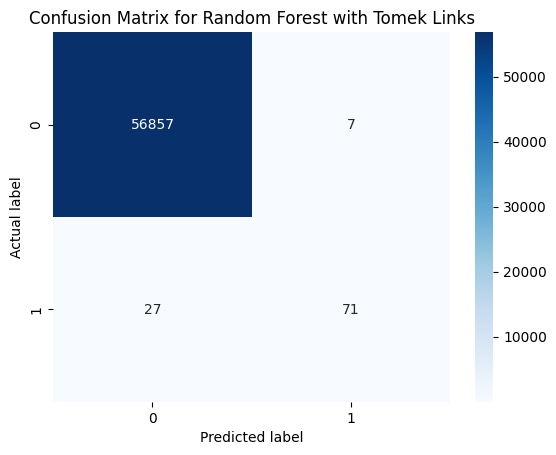

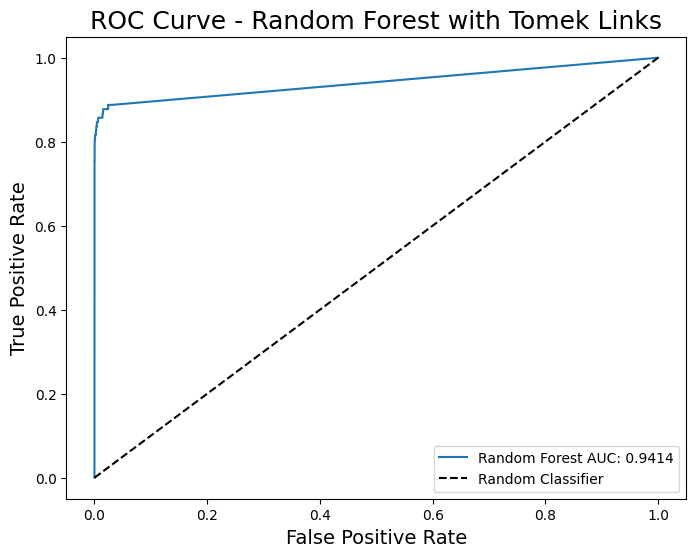

In [52]:


# Train Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    oob_score=True,
    n_jobs=-1,
    random_state=1
)

rf.fit(x_train_tl, y_train_tl)

# Predictions and evaluation
y_pred_rf_tl = rf.predict(x_test)
y_pred_proba_rf_tl = rf.predict_proba(x_test)[:, 1]

# Training Accuracy
train_accuracy = accuracy_score(y_train_tl, rf.predict(x_train_tl))
print(f"Training Accuracy: {train_accuracy:.4f}")

# Cross-Validation Score
cv_scores = cross_val_score(rf, x_train_tl, y_train_tl, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# AUC-ROC Calculation
rf_auc = roc_auc_score(y_test, y_pred_proba_rf_tl)
print(f"AUC-ROC Score: {rf_auc:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_rf_tl))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf_tl), annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix for Random Forest with Tomek Links')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

# Plot the ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_pred_proba_rf_tl)
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - Random Forest with Tomek Links', fontsize=18)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC: {rf_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()


## XGBoost Using Tomek

In [ ]:
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             accuracy_score)
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import TomekLinks

# Apply Tomek Links resampling
tl = TomekLinks(sampling_strategy='majority')
x_train_tl, y_train_tl = tl.fit_resample(x_train, y_train)

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=30,
    learning_rate=0.01,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(x_train_tl, y_train_tl)

# Predictions and evaluation
y_pred_xgb = xgb_model.predict(x_test)
y_pred_proba_xgb = xgb_model.predict_proba(x_test)[:, 1]

# Training Accuracy
train_accuracy = accuracy_score(y_train_tl, xgb_model.predict(x_train_tl))
print(f"Training Accuracy: {train_accuracy:.4f}")

# Cross-Validation Score
cv_scores = cross_val_score(xgb_model, x_train_tl, y_train_tl, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# AUC-ROC Calculation
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"AUC-ROC Score: {xgb_auc:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix for XGBoost with Tomek Links')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

# Plot the ROC Curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - XGBoost with Tomek Links', fontsize=18)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost AUC: {xgb_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()


##Logistic Regression Using Tomek

Training Accuracy: 0.9992
Cross-Validation Accuracy: 0.9992 (+/- 0.0000)
AUC-ROC Score: 0.9682
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.61      0.71        98

    accuracy                           1.00     56962
   macro avg       0.93      0.81      0.86     56962
weighted avg       1.00      1.00      1.00     56962



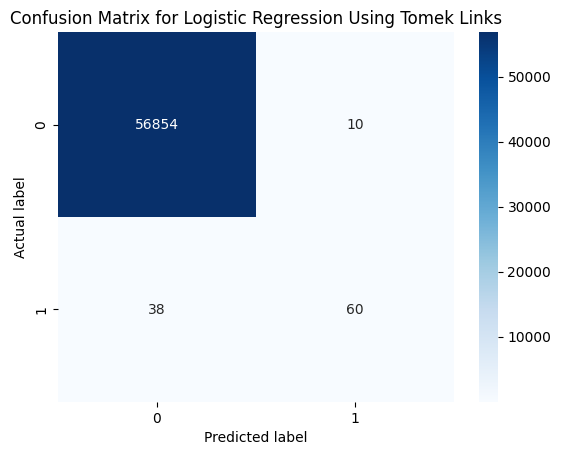

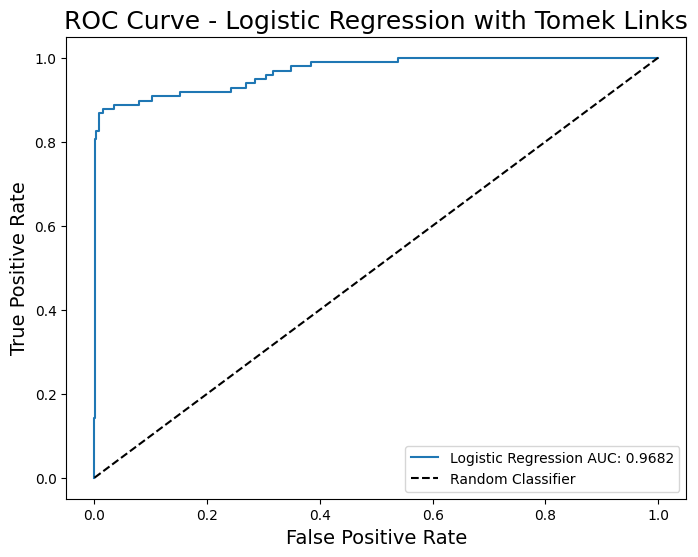

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             accuracy_score)
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import TomekLinks

# Apply Tomek Links resampling
tl = TomekLinks(sampling_strategy='majority')
x_train_tl, y_train_tl = tl.fit_resample(x_train, y_train)

# Initialize Logistic Regression Model
logreg_model = LogisticRegression(max_iter=1000)

# Train the model
logreg_model.fit(x_train_tl, y_train_tl)

# Predictions and evaluation
y_pred_logreg_tl = logreg_model.predict(x_test)
y_pred_proba_logreg_tl = logreg_model.predict_proba(x_test)[:, 1]

# Training Accuracy
train_accuracy = accuracy_score(y_train_tl, logreg_model.predict(x_train_tl))
print(f"Training Accuracy: {train_accuracy:.4f}")

# Cross-Validation Score
cv_scores = cross_val_score(logreg_model, x_train_tl, y_train_tl, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# AUC-ROC Calculation
logreg_auc = roc_auc_score(y_test, y_pred_proba_logreg_tl)
print(f"AUC-ROC Score: {logreg_auc:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_logreg_tl))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_tl), annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix for Logistic Regression Using Tomek Links')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

# Plot the ROC Curve
logreg_fpr, logreg_tpr, _ = roc_curve(y_test, y_pred_proba_logreg_tl)
plt.figure(figsize=(8, 6))
plt.title('ROC Curve - Logistic Regression with Tomek Links', fontsize=18)
plt.plot(logreg_fpr, logreg_tpr, label=f'Logistic Regression AUC: {logreg_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.show()
